<strong><center><h1> RandomForest

In [5]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

from src.ModelEvaluator.main.core import ModelEvaluator

In [6]:
data = pd.read_csv('../../../../data/processed_data/train_models_data/data_with_PCA/data_with_generated_features/AgglomerativeClustering_generated_features_PCA.csv')

X = data.drop('Cluster', axis=1)
y = data['Cluster']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f'Accuracy: {accuracy}')

Accuracy: 0.9737654320987654


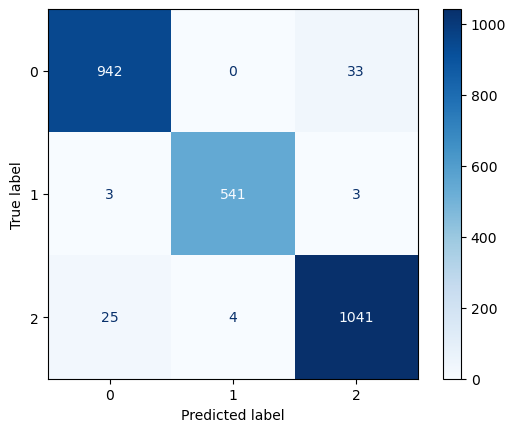

In [7]:
cm = confusion_matrix(y_test, y_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_model.classes_)
cm_display.plot(cmap='Blues');

In [8]:
evaluator = ModelEvaluator(
    data,
    target_column='Cluster',
    random_state=42
)

metrics = evaluator.evaluate_clustering()
metrics

,Value
Metric,
Silhouette,0.209
Calinski Harabasz,2398.566
Davies Bouldin,1.681
